In [4]:
import pandas as pd
import matplotlib as plt
import numpy as np
import openpyxl
from datetime import datetime

list of target columns

In [5]:
TARGET_COLUMNS = [
  'agronomist_name', 
    'farmer', 
    'name', 
    'region', 
    'province',
    'status', 
    'total_area', 
    'engaged_area', 
    'area',
    'parcels',
    'agronomist_join_date', 
    'farmer_creation_date', 
    'acquisition_channel',
    'cohort', 
    'link', 
    'farmer_id', 
    'agronomist_id', 
    'parcel_id',
    'phone_number',
    'gov_id_type',
    'gov_id']


Read excel sheets

In [ ]:
df = pd.read_excel(
r'file_path\all_parcels_2026-02-09T10_09_15.413678Z.xlsx',
    sheet_name='sheet1'
)

In [7]:
df.columns

Index(['agronomist_name', 'farmer', 'country', 'region', 'province', 'status',
       'engaged_area', 'agronomist_join_date', 'farmer_creation_date',
       'acquisition_channel',
       ...
       'role', 'language_preference', 'superior_id', 'updated_by_id.2',
       'latest_mobile_app_version', 'is_for_test.2', 'deleted_by_id.2',
       'acquisition_channel.2', 'profile_picture_name', 'watershed'],
      dtype='str', length=163)

In [8]:
#the dataset is full of columns that are not need for the particular 
# analysis i am going to carry out, so i will be dropping them 

In [9]:
#to ensure that spaces before or after in columns do not cause problems 
df.columns = df.columns.str.strip()


Drop all unwanted columns


In [10]:
df = df[[col for col in TARGET_COLUMNS if col in df.columns]]


In [11]:
df.columns

Index(['agronomist_name', 'farmer', 'name', 'region', 'province', 'status',
       'total_area', 'engaged_area', 'area', 'parcels', 'agronomist_join_date',
       'farmer_creation_date', 'acquisition_channel', 'cohort', 'link',
       'farmer_id', 'agronomist_id', 'parcel_id', 'phone_number',
       'gov_id_type', 'gov_id'],
      dtype='str')

In [ ]:
Channel_1_AGRONOMISTS = [
    'Agronomist_1',
    'Agronomist_2',
    'Agronomist_4',
    'Agronomist_3',
    'Agronomist_5'
]


In [ ]:
def assign_channel(agronomist_name):
    if pd.isna(agronomist_name):
        return "Channel_0"
    elif agronomist_name in Channel_1_AGRONOMISTS:
        return "channel_1"
    elif agronomist_name == "C_Proc":
        return "Channel_2"
    else:
        return "Channel_0"
    


df['Aquisition Channel'] = df['agronomist_name'].apply(assign_channel)

In [ ]:
df['Aquisition Channel'].value_counts()

In [15]:
def classify_area(area):
    if pd.isna(area):
        return None
    elif area < 0.1:
        return "< 0.1 ha"
    elif area <= 0.6:
        return "0.1-0.6 ha"
    elif area <= 1:
        return "0.6-1 ha"
    elif area <= 5:
        return "1-5 ha"
    elif area <= 10:
        return "5-10 ha"
    elif area <= 15:
        return "10-15 ha"
    else:
        return "> 15 ha"



In [16]:
df.insert(
    loc=df.columns.get_loc('parcels'),
    column='Class_range',
    value=df['area'].apply(classify_area)
)


In [17]:
df.columns

Index(['agronomist_name', 'farmer', 'name', 'region', 'province', 'status',
       'total_area', 'engaged_area', 'area', 'Class_range', 'parcels',
       'agronomist_join_date', 'farmer_creation_date', 'acquisition_channel',
       'cohort', 'link', 'farmer_id', 'agronomist_id', 'parcel_id',
       'phone_number', 'gov_id_type', 'gov_id', 'Aquisition Channel'],
      dtype='str')

In [18]:
def Eligible_Engaged(engaged_area):
    if pd.isna(engaged_area):
        return None
    elif engaged_area <0.6:
        return "NO"
    else:
        return "YES"
    
df['Farmer_Eligibility'] = df['engaged_area'].apply(Eligible_Engaged)

In [19]:
df.columns

Index(['agronomist_name', 'farmer', 'name', 'region', 'province', 'status',
       'total_area', 'engaged_area', 'area', 'Class_range', 'parcels',
       'agronomist_join_date', 'farmer_creation_date', 'acquisition_channel',
       'cohort', 'link', 'farmer_id', 'agronomist_id', 'parcel_id',
       'phone_number', 'gov_id_type', 'gov_id', 'Aquisition Channel',
       'Farmer_Eligibility'],
      dtype='str')

In [20]:

df['farmer_creation_date'] = pd.to_datetime(df['farmer_creation_date'])

In [21]:
df.columns

Index(['agronomist_name', 'farmer', 'name', 'region', 'province', 'status',
       'total_area', 'engaged_area', 'area', 'Class_range', 'parcels',
       'agronomist_join_date', 'farmer_creation_date', 'acquisition_channel',
       'cohort', 'link', 'farmer_id', 'agronomist_id', 'parcel_id',
       'phone_number', 'gov_id_type', 'gov_id', 'Aquisition Channel',
       'Farmer_Eligibility'],
      dtype='str')

In [22]:
#these the numbers of parcels owned by eligible farmers
df['Farmer_Eligibility'].value_counts()

Farmer_Eligibility
YES    40150
NO      2998
Name: count, dtype: int64

<Axes: xlabel='farmer_creation_date'>

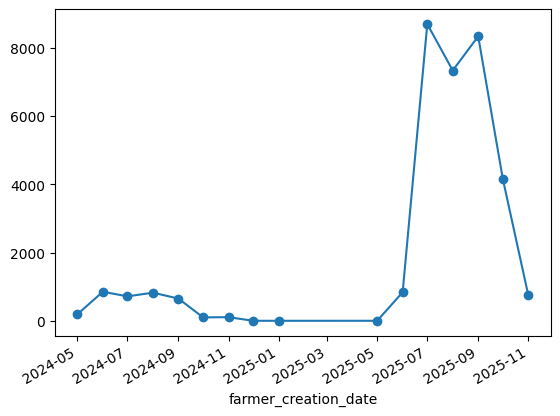

In [ ]:

monthly_farmers = (
    df
    .groupby(df['farmer_creation_date'].dt.to_period('M'))['farmer_id']
    .nunique()
)

monthly_farmers.index = monthly_farmers.index.to_timestamp()

monthly_farmers.plot(kind='line', marker='o')



In [ ]:
#Exporting data for further analysis and visualisation in excel and POWER BI
today = datetime.today().strftime('%d_%m_%Y')

df.to_excel(f"All_parcels_cleaned_{today}.xlsx", index=False)
